# Networkx graph

The pandapower network of a grid can be converted into a networkx graph. The graph can be drawn as a tree, and graph searches can be performed on it, e.g. the cable length from the transformer to each consumer.

**Prerequisites**

- pylovo installed with the `notebooks` extra (`uv sync --extra notebooks`) and this notebook running on the kernel of the project environment (`.venv`), see `notebook_tutorials/README.md`.
- A `.env` in the repository root that points to your pylovo database, a completed `pylovo-setup` and generated grids for the postcode area (PLZ) below, e.g. `pylovo-generate --plz 85653`.
- Grids are read for the `VERSION_ID` of `config/config_generation.yaml`.

The stored outputs were generated for the demo postcode area 85653 (Aying), whose buildings, streets and transformers are derived from OpenStreetMap. Map data © OpenStreetMap contributors (ODbL).

In [1]:
# Parameters
plz = 85653  # postcode area with generated grids
kcid = None  # k-means cluster id of the grid; None: first grid of the PLZ
bcid = None  # building cluster id of the grid; None: first grid of the PLZ

## Setup

In [2]:
import warnings

import networkx as nx
import pandas as pd
import pandapower.topology as top
import plotly.io as pio

from pylovo.config_loader import VERSION_ID
from pylovo.database.database_client import DatabaseClient
from pylovo.plotting.generation.networks import (
    draw_radial_network,
    draw_tree_network,
    draw_tree_network_spacing,
    plot_simple_grid,
)

warnings.filterwarnings("ignore")
# pandapower's plotly functions select the "notebook" renderer, which embeds the complete
# plotly.js (about 4.7 MB) for every figure. The CDN variant keeps this notebook small.
pio.renderers["notebook"] = pio.renderers["notebook_connected"]


In [3]:
dbc = DatabaseClient()  # read-only access (GridGenerator is only needed to generate grids)
cluster_list = dbc.get_list_from_plz(plz)
if not cluster_list:
    raise ValueError(f"No grids of version {VERSION_ID} for PLZ {plz}. Run: pylovo-generate --plz {plz}")
if kcid is None or bcid is None:
    kcid, bcid = cluster_list[0]
print(f"PLZ {plz}, version {VERSION_ID}: {len(cluster_list)} grids; selected kcid={kcid}, bcid={bcid}")

PLZ 85653, version 1: 4 grids; selected kcid=1, bcid=1


## Recall
The pandapower network:

In [4]:
plot_simple_grid(plz=plz, kcid=kcid, bcid=bcid)

## Networkx graph representation
networkx provides visualisation tools and graph search functions. We convert the pandapower network into a networkx graph:

In [5]:
net = dbc.read_net_db(plz=plz, kcid=kcid, bcid=bcid)
G = top.create_nxgraph(net)

We display the graph as a tree.

**Nodes**
- the buses are represented by nodes; the node number is the bus index
- the root (top node) is the MV bus (index 1), below it the LV bus of the transformer (index 0)
- the leaves (lowest node of each branch) are the consumer buses
- the nodes in between are connection buses

**Edges**
- the lines (and the transformer) are represented by edges
- the edge weight is the cable length in km (0 for the transformer)

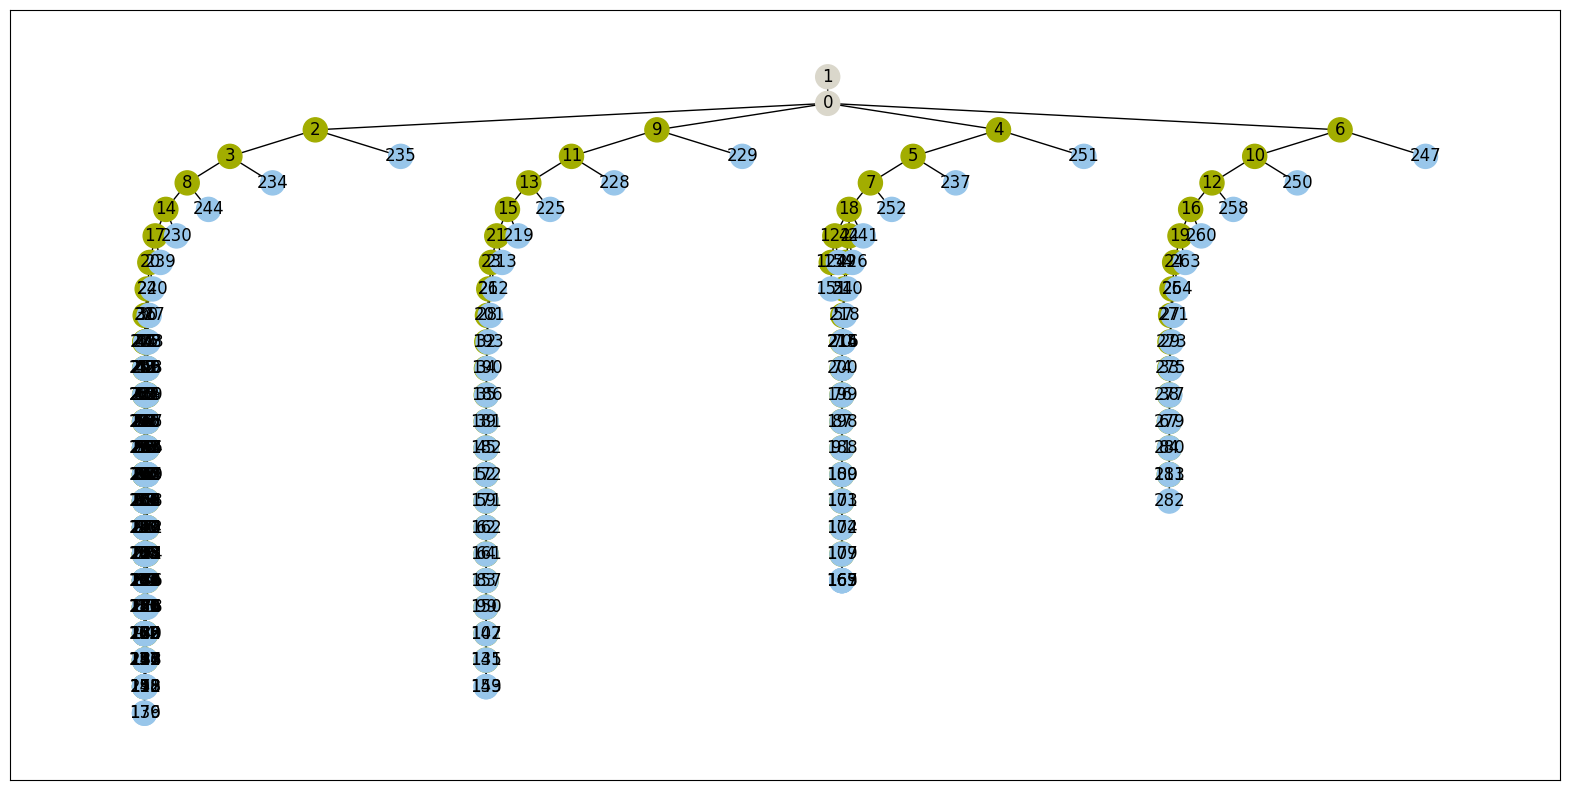

In [6]:
draw_tree_network(G)

Node colours (`NETWORK_COLORS` in `config/config_analysis.yaml`): transformer buses, connection buses and consumer buses.

In larger graphs nodes may overlap. The nodes can also be spaced evenly per level:

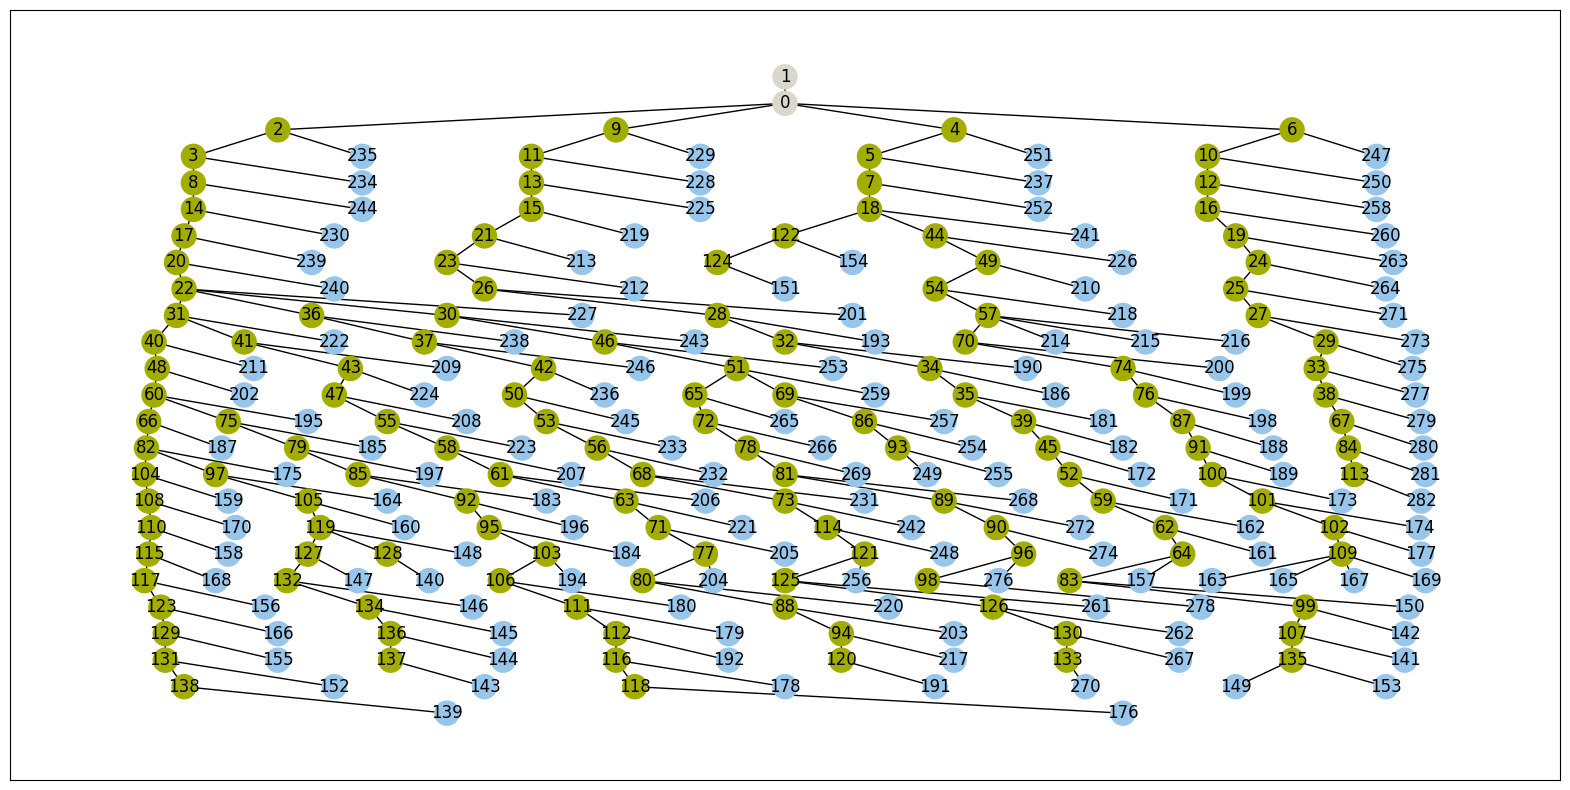

In [7]:
draw_tree_network_spacing(G)

The graph in a radial layout:

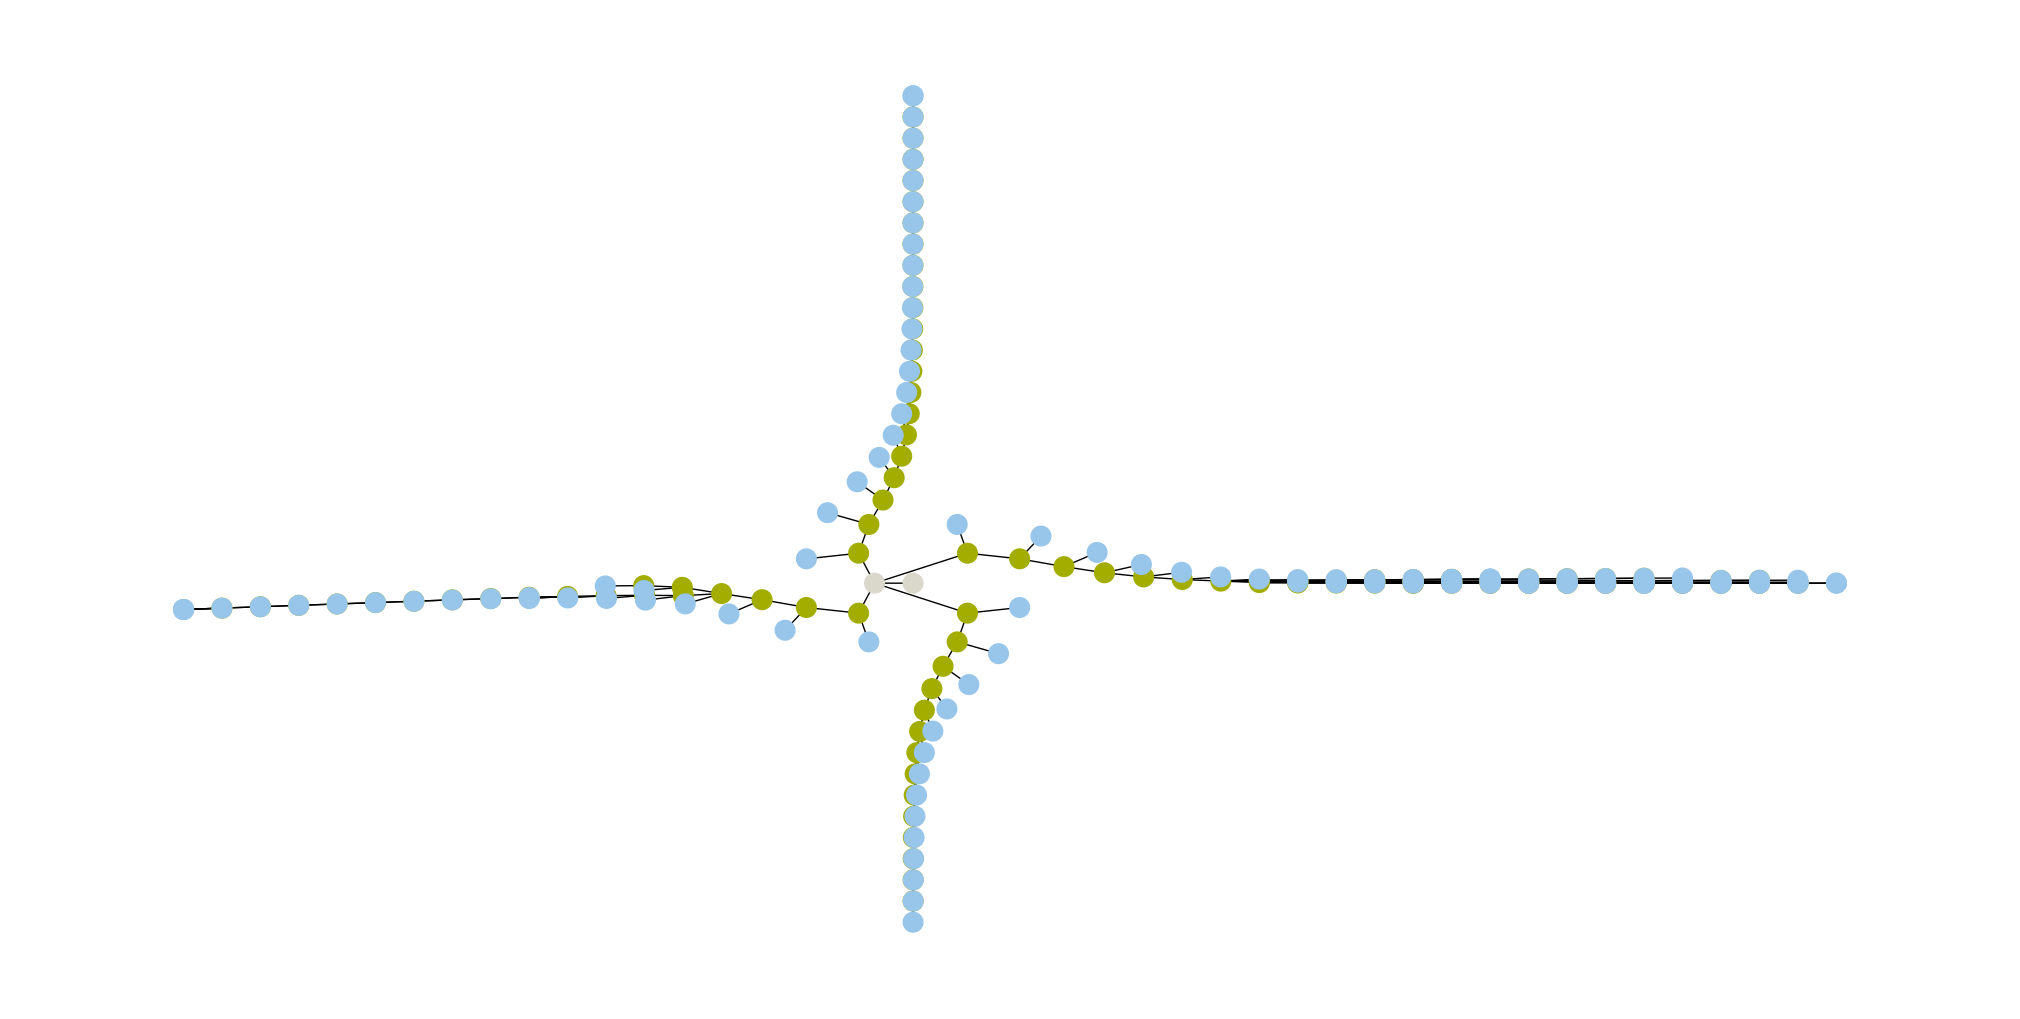

In [8]:
draw_radial_network(G)

## Graph search
Graph search algorithms can be run on the graph, e.g. the weighted path length (cable length in km) from the transformer LV bus (index 0) to the first consumer bus:

In [9]:
root = 0  # LV bus of the transformer
consumer_buses = list(net.bus.index[net.bus["name"].str.contains("Consumer Nodebus")])
print(f"{nx.dijkstra_path_length(G, root, consumer_buses[0]):.3f} km")

0.549 km


The path length from the transformer to each consumer bus (km):

In [10]:
path_length_km = pd.Series(
    {bus: nx.dijkstra_path_length(G, root, bus) for bus in consumer_buses}, name="path_length_km"
)
path_length_km.round(3).head(10)

139    0.549
140    0.370
141    0.300
142    0.284
143    0.438
144    0.415
145    0.397
146    0.378
147    0.357
148    0.334
Name: path_length_km, dtype: float64

The number of consumer buses (`count`), the average path length (`mean`) and the path length to the furthest consumer (`max`):

In [11]:
path_length_km.describe().round(3)

count    144.000
mean       0.239
std        0.093
min        0.020
25%        0.186
50%        0.244
75%        0.300
max        0.549
Name: path_length_km, dtype: float64